# **UVA DS4002 Project 2 - Duo Lingo**
### Analysis code that calculates correlation between Duo Lingo search interest and company metrics (DAU, revenue, etc.)

**Code Purpose:** This code loads search-interest and Duolingo performance data, computes contemporaneous and lagged correlations (Pearson and Spearman), summarizes them in a table, and generates scatter plots with regression lines to visualize how search interest relates to DAU, paid subscribers, and revenue across current and future quarters.

### **IMPORTANT:** In order for code to run you must download activity_data_final.csv and dau_data_final.csv



── CONTEMPORANEOUS CORRELATIONS (same quarter) ──

DAU:
  Pearson  r=0.474, p=0.0639 
  Spearman r=0.356, p=0.1754 

Paid_Subscribers:
  Pearson  r=0.472, p=0.0651 
  Spearman r=0.356, p=0.1754 

Revenue:
  Pearson  r=0.421, p=0.1040 
  Spearman r=0.356, p=0.1754 

── LAGGED CORRELATIONS ──

  Lag = 1 quarter(s) ahead:
  DAU:
    Pearson  r=0.525, p=0.0446 ✓ SIGNIFICANT
    Spearman r=0.408, p=0.1313 
  Paid_Subscribers:
    Pearson  r=0.526, p=0.0440 ✓ SIGNIFICANT
    Spearman r=0.408, p=0.1313 
  Revenue:
    Pearson  r=0.497, p=0.0594 
    Spearman r=0.408, p=0.1313 

  Lag = 2 quarter(s) ahead:
  DAU:
    Pearson  r=0.635, p=0.0147 ✓ SIGNIFICANT
    Spearman r=0.559, p=0.0378 ✓ SIGNIFICANT
  Paid_Subscribers:
    Pearson  r=0.633, p=0.0150 ✓ SIGNIFICANT
    Spearman r=0.559, p=0.0378 ✓ SIGNIFICANT
  Revenue:
    Pearson  r=0.625, p=0.0168 ✓ SIGNIFICANT
    Spearman r=0.559, p=0.0378 ✓ SIGNIFICANT

── SUMMARY TABLE ──
          Metric  Lag  Pearson_r  p_value  Significant
         

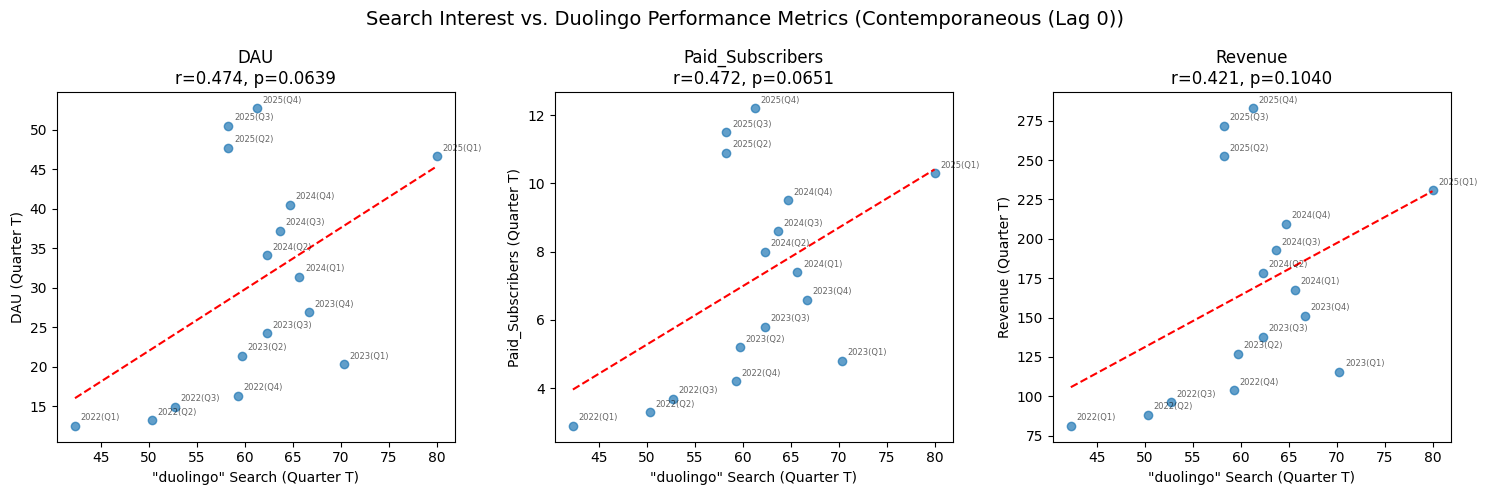

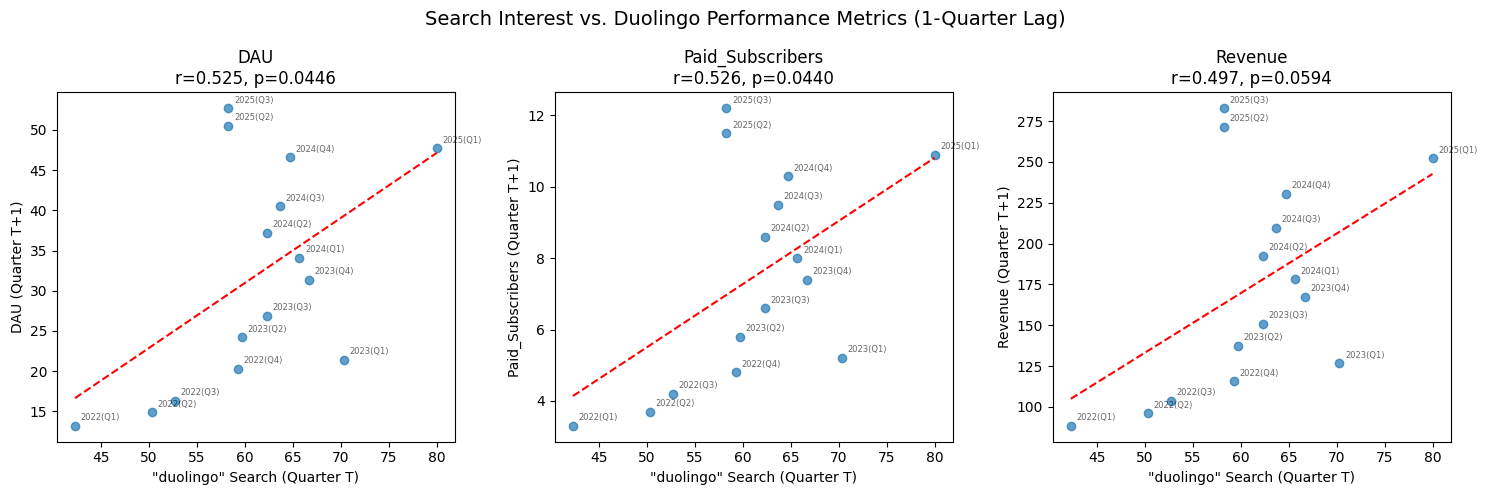

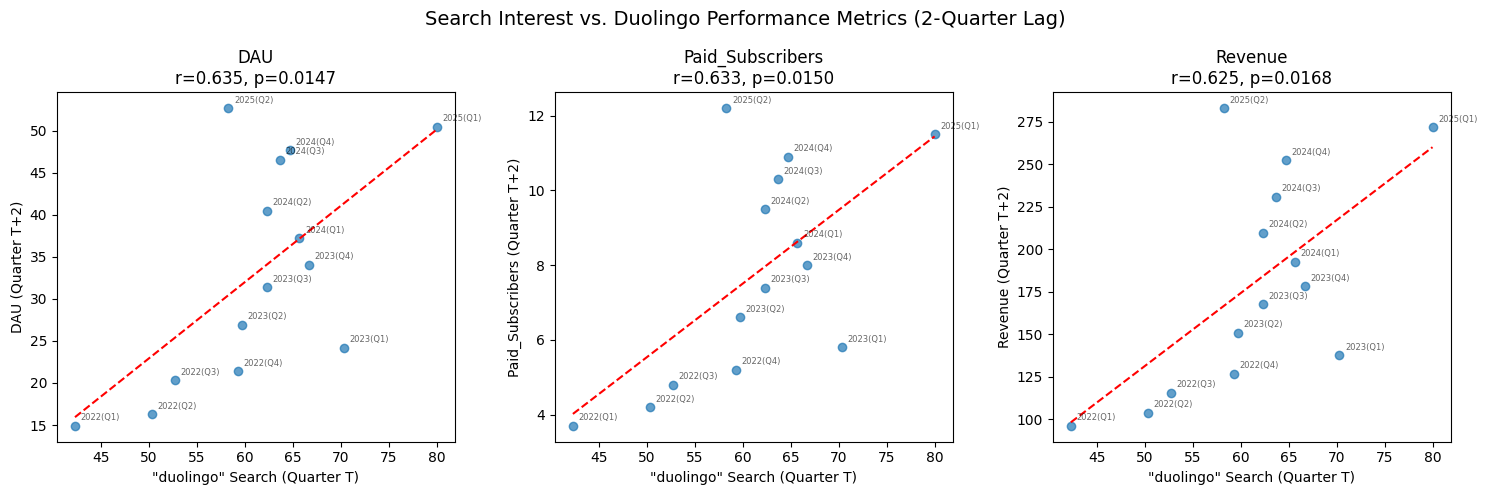

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ── STEP 1: Load the data ──────────────────────────────────────────────────
# (Assuming your files exist in the same directory)
# Load quarterly Google search interest (e.g., for "duolingo")
search = pd.read_csv('activity_data_final.csv')
# Load quarterly Duolingo performance metrics (DAU, subscribers, revenue, etc.)
revenue = pd.read_csv('dau_data_final.csv')

# ── STEP 2: Align on the same index ───────────────────────────────────────
# Merge the two datasets on the shared 'Period' column so each row represents the same quarter
df = pd.merge(search, revenue, on='Period')

# ── STEP 3: Pearson + Spearman correlations ────────────────────────────────
# Name of the search-interest column to correlate with performance metrics
search_col = 'duolingo'
# List of performance metrics to analyze against search interest
metrics    = ['DAU', 'Paid_Subscribers', 'Revenue']

print("\n── CONTEMPORANEOUS CORRELATIONS (same quarter) ──")
# Loop over each performance metric and compute correlations with search interest
for metric in metrics:
    # Pearson correlation (linear relationship) between search interest and the metric in the same quarter
    r_p, p_p = stats.pearsonr(df[search_col],  df[metric])
    # Spearman correlation (rank-based, monotonic relationship) for the same quarter
    r_s, p_s = stats.spearmanr(df[search_col], df[metric])
    print(f"\n{metric}:")
    # Print Pearson r and p-value, flagging if statistically significant at p < 0.05
    print(f"  Pearson  r={r_p:.3f}, p={p_p:.4f} {'✓ SIGNIFICANT' if p_p < 0.05 else ''}")
    # Print Spearman r and p-value, also flagging significance
    print(f"  Spearman r={r_s:.3f}, p={p_s:.4f} {'✓ SIGNIFICANT' if p_s < 0.05 else ''}")

# ── STEP 4: Lagged correlations ────────────────────────────────────────────
# Here we test whether search interest in one quarter predicts metrics 1 or 2 quarters ahead
print("\n── LAGGED CORRELATIONS ──")
for lag in [1, 2]:
    print(f"\n  Lag = {lag} quarter(s) ahead:")
    # For a given lag, align search interest at time T with metrics at time T+lag
    # Drop the last 'lag' observations from search so lengths match
    search_lagged = df[search_col].iloc[:-lag].values
    for metric in metrics:
        # Take the metric values starting 'lag' quarters into the future
        metric_future = df[metric].iloc[lag:].values
        # Pearson correlation between search interest at T and metric at T+lag
        r_p, p_p = stats.pearsonr(search_lagged,  metric_future)
        # Spearman correlation between search interest at T and metric at T+lag
        r_s, p_s = stats.spearmanr(search_lagged, metric_future)
        print(f"  {metric}:")
        print(f"    Pearson  r={r_p:.3f}, p={p_p:.4f} {'✓ SIGNIFICANT' if p_p < 0.05 else ''}")
        print(f"    Spearman r={r_s:.3f}, p={p_s:.4f} {'✓ SIGNIFICANT' if p_s < 0.05 else ''}")

# ── STEP 5: Summary table ──────────────────────────────────────────────────
# Build a compact summary table of Pearson correlations and significance for lags 0, 1, and 2
rows = []
for lag in [0, 1, 2]:
    for metric in metrics:
        if lag == 0:
            # Contemporaneous correlation: same quarter for search and metric
            r, p = stats.pearsonr(df[search_col], df[metric])
        else:
            # Lagged correlation: search at T vs metric at T+lag
            r, p = stats.pearsonr(df[search_col].iloc[:-lag], df[metric].iloc[lag:])

        # Append a row summarizing the metric, lag, correlation, p-value, and a simple significance flag
        rows.append({
            'Metric': metric,
            'Lag': lag,
            'Pearson_r': round(r, 3),
            'p_value': round(p, 4),
            # Mark as "Significant" if p < 0.05 and effect size is reasonably strong (|r| > 0.5)
            'Significant': p < 0.05 and abs(r) > 0.5
        })

# Convert the list of dictionaries into a DataFrame for a clean tabular summary
summary = pd.DataFrame(rows)
print("\n── SUMMARY TABLE ──")
# Print the summary table without row indices
print(summary.to_string(index=False))

# ── STEP 6: Visualization (Lags 0, 1, and 2) ───────────────────────────────
# We loop through 0, 1, and 2 to generate three separate sets of scatter plots with trend lines
for lag in [0, 1, 2]:
    # Slice the data based on lag to align search and metric values correctly
    if lag == 0:
        # No lag: use all quarters as-is
        search_values = df[search_col].values
        period_labels = df['Period'].values
        lag_title = "Contemporaneous (Lag 0)"
        lag_label = "T"
    else:
        # For lagged plots, drop the last 'lag' quarters from search and labels
        search_values = df[search_col].iloc[:-lag].values
        period_labels = df['Period'].iloc[:-lag].values
        lag_title = f"{lag}-Quarter Lag"
        lag_label = f"T+{lag}"

    # Create a row of 3 subplots, one for each performance metric
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    # Overall title describing which lag is being visualized
    fig.suptitle(f'Search Interest vs. Duolingo Performance Metrics ({lag_title})', fontsize=14)

    # Iterate over each metric and corresponding subplot axis
    for i, metric in enumerate(metrics):
        ax = axes[i]

        # Determine the metric values aligned with the current lag
        if lag == 0:
            # Same-quarter values
            metric_values = df[metric].values
        else:
            # Future metric values (shifted by 'lag' quarters)
            metric_values = df[metric].iloc[lag:].values

        # Scatter plot of search interest vs. the chosen metric
        ax.scatter(search_values, metric_values, alpha=0.7)

        # Label each point with its quarter (Period) for interpretability
        for j, label in enumerate(period_labels):
            ax.annotate(label, (search_values[j], metric_values[j]),
                        fontsize=6, alpha=0.6, textcoords="offset points", xytext=(4, 4))

        # Trend line: fit a simple linear regression (y = m*x + b) using numpy.polyfit
        m, b = np.polyfit(search_values, metric_values, 1)
        # Generate x-values spanning the range of search interest
        x_line = np.linspace(search_values.min(), search_values.max(), 100)
        # Plot the regression line as a dashed red line
        ax.plot(x_line, m * x_line + b, 'r--')

        # Compute Pearson correlation for this specific lag and metric to show on the plot
        r, p = stats.pearsonr(search_values, metric_values)
        # Title includes metric name and correlation statistics
        ax.set_title(f'{metric}\nr={r:.3f}, p={p:.4f}')
        # X-axis: search interest in quarter T
        ax.set_xlabel(f'"{search_col}" Search (Quarter T)')
        # Y-axis: metric in quarter T or T+lag, depending on the current lag
        ax.set_ylabel(f'{metric} (Quarter {lag_label})')

    # Adjust layout to prevent overlapping labels and titles
    plt.tight_layout()
    # Save the figure to a PNG file named according to the lag
    plt.savefig(f'correlation_plots_lag{lag}.png', dpi=150)
    # Display the figure
    plt.show()
